In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from data_handler import EleHandler
from classifier import Classifier
from backbone import Backbone
from concept_head import ConceptHead
from retrieval import Retrieval
from projector import Projector

from torch.utils.data import DataLoader, Subset
from torch.utils.data.sampler import RandomSampler
from torch.utils.data import DataLoader, SequentialSampler

import torch, math
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import random
import torch.nn.functional as F

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

# Check if train and test indices intersect
print("Intersection of train and test indices:", set(train_indices) & set(test_indices))

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=512, shuffle=False)

Intersection of train and test indices: set()


# Defining metrics

We have two different subset : train and test. 
- Training will be happening on the train set. Training performance is evaluated in the one-out setting on this subset. Each image is sequecially used as the query and all the other images are used as the gallery. Concretely, this is done by using the embeddings as both the query and the gallery in the similarity matrix, then the diagonal is removed.
- Testing is happening with the train set as the gallery and the test set as the query. We average the query-recall over the whole query set.


ArcFace tutorial : https://yiwenlai.medium.com/how-to-train-with-arcface-loss-to-improve-model-classification-accuracy-d4035195aeb9

## Baseline-1 : retrieval on MegDescriptor pretrained on savannah elephants

evaluating backbone
Train Recalls:
Recall@1: 5.40%
Recall@5: 11.81%
Recall@10: 16.96%
Recall@20: 23.78%
Recall@100: 49.22%
Test Recalls:
Recall@1: 19.19%
Recall@5: 31.76%
Recall@10: 39.15%
Recall@20: 46.76%
Recall@100: 72.89%


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:364: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


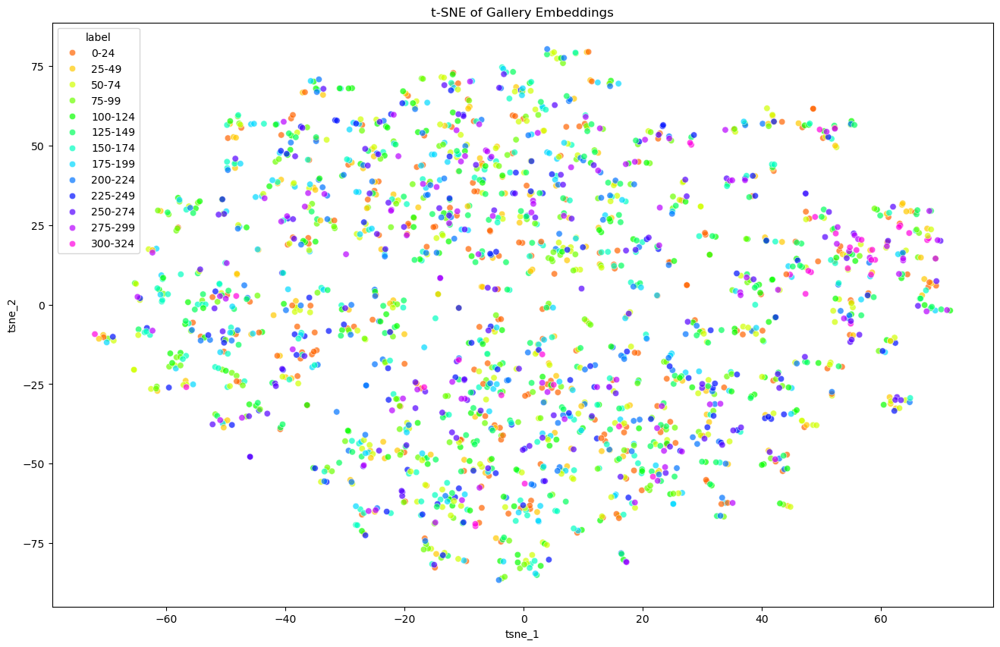

<Figure size 640x480 with 0 Axes>

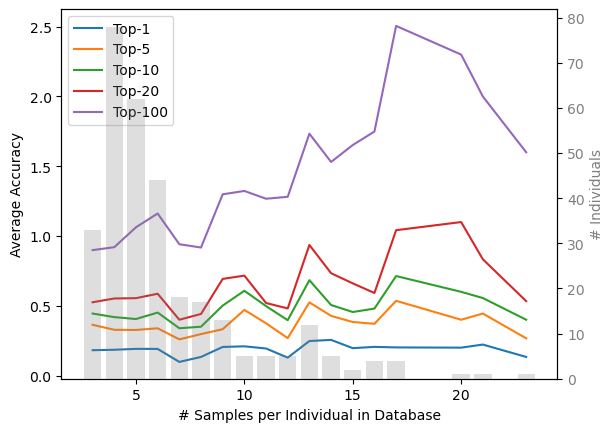

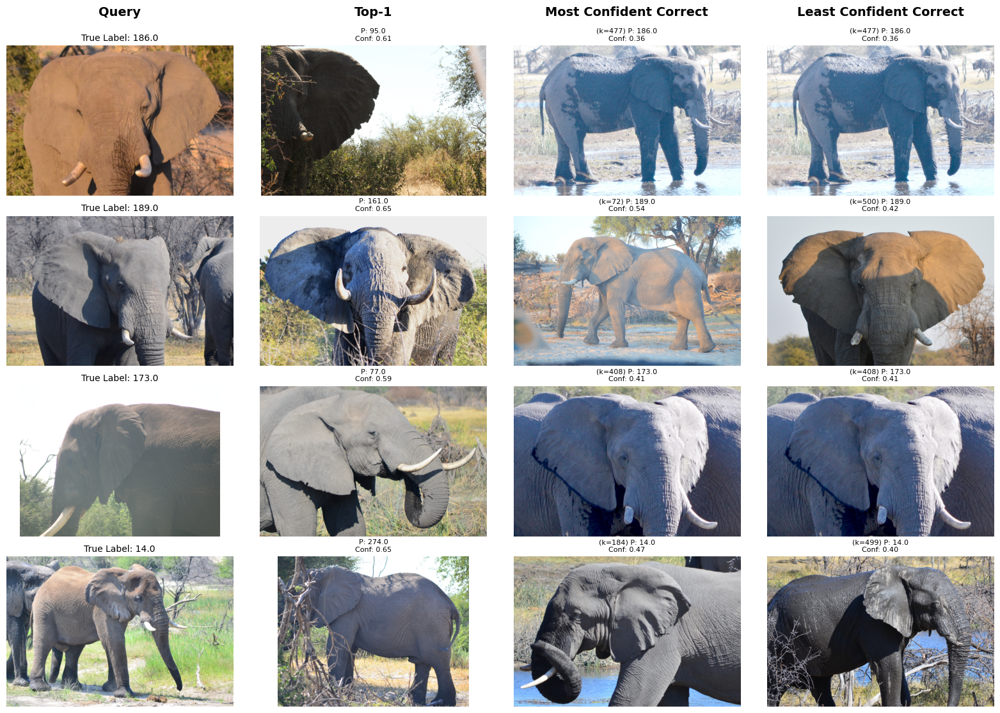

<Figure size 640x480 with 0 Axes>

In [10]:
code = 'baseline-1-MD'
r11 = Retrieval(experiment_code=code)

MD = Backbone(with_ears = True, pretraining = "savannah-elephants", experiment_code=code)
r11.evaluate_model(MD, train_loader, test_loader)

# Baseline-1.2 : Miew-ID

Building Model Backbone for efficientnetv2_rw_m model
config.model_name efficientnetv2_rw_m
model_name efficientnetv2_rw_m
final_in_features 2152
evaluating backbone
Train Recalls:
Recall@1: 4.54%
Recall@5: 9.34%
Recall@10: 12.92%
Recall@20: 18.63%
Recall@100: 42.76%
Test Recalls:
Recall@1: 12.19%
Recall@5: 20.18%
Recall@10: 25.21%
Recall@20: 31.84%
Recall@100: 58.64%


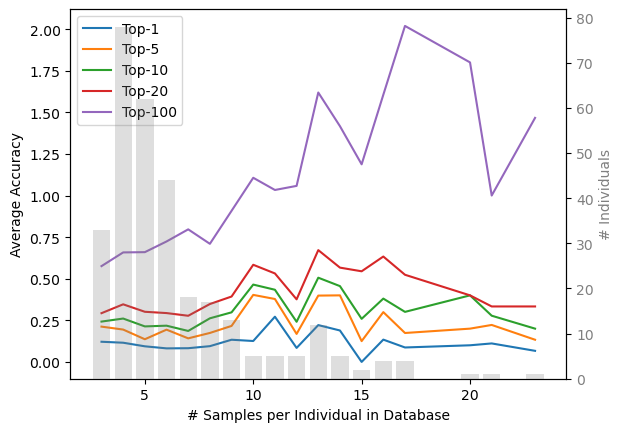

In [11]:
code = 'baseline-1-Miew'
r12 = Retrieval(experiment_code=code)

miew = Backbone(with_ears = True, model_name = 'MiewID-msv3', experiment_code=code)
r12.evaluate_model(miew, train_loader, test_loader, show_matches = False, show_tsne = False)

## Baseline-2 : fine-tuning MD with ArcFace

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Backbone parameters require gradients: True
Epoch 1/5 - Train Loss: 6.8984, BATCH-Recall@1: 1.01%, --- EPOCH - Recall@1: 7.42%, Recall@5: 12.72%, Recall@20: 22.87%, Recall@100: 46.64%
Epoch 2/5 - Train Loss: 6.2319, BATCH-Recall@1: 0.60%, --- EPOCH - Recall@1: 7.02%, Recall@5: 14.03%, Recall@20: 24.28%, Recall@100: 47.55%
Epoch 3/5 - Train Loss: 5.6767, BATCH-Recall@1: 1.06%, --- EPOCH - Recall@1: 9.29%, Recall@5: 16.15%, Recall@20: 26.80%, Recall@100: 51.39%
Epoch 4/5 - Train Loss: 4.5970, BATCH-Recall@1: 1.21%, --- EPOCH - Recall@1: 12.37%, Recall@5: 22.16%, Recall@20: 36.45%, Recall@100: 61.53%
Epoch 5/5 - Train Loss: 3.2661, BATCH-Recall@1: 1.71%, --- EPOCH - Recall@1: 18.22%, Recall@5: 31.80%, Recall@20: 48.01%, Recall@100: 73.95%
evaluating backbone
Train Recalls:
Recall@1: 18.22%
Recall@5: 31.80%
Recall@10: 39.12%
Recall@20: 48.01%
Recall@100: 73.95%
Test Recalls:
Recall@1: 24.14%
Recall@5: 36.33%
Recall@10: 43.87%
Recall@20: 51.87%
Recall@100: 75.32%


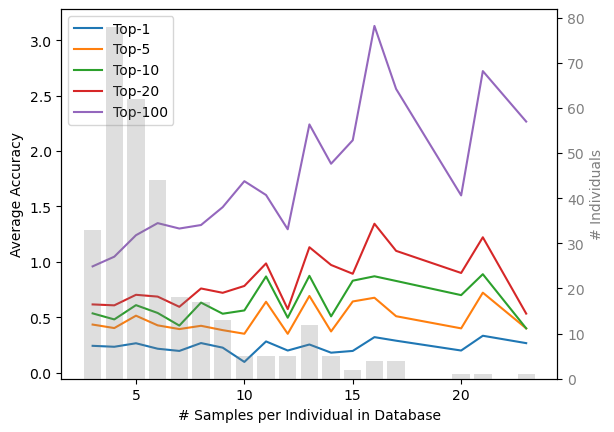

In [15]:
# Because we are working on a bigger model, we have to reduce the batch size
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

code = 'baseline-2-MD'
r21 = Retrieval(experiment_code=code)

MD = Backbone(with_ears = True, lr = 1e-4, pretraining = "savannah_elephants", experiment_code=code)
MD.train(train_loader, val_loader=train_loader, num_epochs=5)

r21.evaluate_model(MD, train_loader, test_loader, show_matches=False, show_tsne=False)

# Baseline 2.2 : Miew Fine-tuned

Backbone parameters require gradients: True
Epoch 1/5 - Train Loss: 6.8597, BATCH-Recall@1: 0.50%, --- EPOCH - Recall@1: 6.66%, Recall@5: 12.32%, Recall@20: 22.56%, Recall@100: 45.53%
Epoch 2/5 - Train Loss: 6.2824, BATCH-Recall@1: 0.25%, --- EPOCH - Recall@1: 6.71%, Recall@5: 11.91%, Recall@20: 21.66%, Recall@100: 46.64%
Epoch 3/5 - Train Loss: 5.8840, BATCH-Recall@1: 0.76%, --- EPOCH - Recall@1: 6.16%, Recall@5: 12.42%, Recall@20: 23.27%, Recall@100: 48.26%
Epoch 4/5 - Train Loss: 5.1224, BATCH-Recall@1: 1.21%, --- EPOCH - Recall@1: 10.95%, Recall@5: 20.24%, Recall@20: 33.06%, Recall@100: 59.26%
Epoch 5/5 - Train Loss: 3.8053, BATCH-Recall@1: 1.81%, --- EPOCH - Recall@1: 15.04%, Recall@5: 27.46%, Recall@20: 43.36%, Recall@100: 68.45%
evaluating backbone
Train Recalls:
Recall@1: 15.04%
Recall@5: 27.46%
Recall@10: 35.18%
Recall@20: 43.36%
Recall@100: 68.45%
Test Recalls:
Recall@1: 24.45%
Recall@5: 37.40%
Recall@10: 42.12%
Recall@20: 50.65%
Recall@100: 74.49%


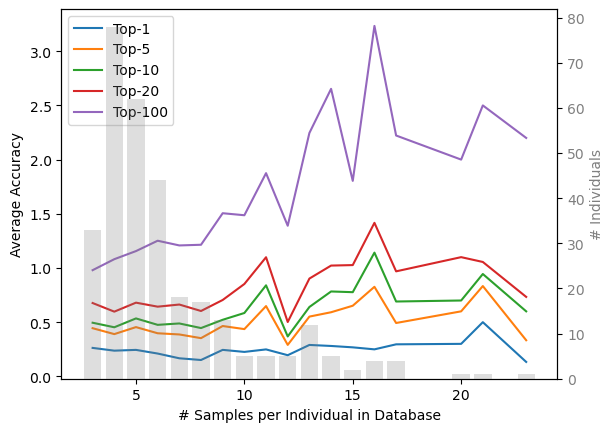

In [16]:
code = 'baseline-2-Miew'
r22 = Retrieval(experiment_code=code)

miew = Backbone(with_ears = True, lr = 1e-4, pretraining = "savannah_elephants", experiment_code=code)
miew.train(train_loader, val_loader=train_loader, num_epochs=5)

r22.evaluate_model(miew, train_loader, test_loader, show_matches=False, show_tsne=False)

# Baseline 3 : CBM retrieval

In [7]:
full_dataset = EleHandler()
indices = np.random.permutation(len(full_dataset))

ch_train_loader = DataLoader(Subset(full_dataset, indices[:int(0.7 * len(indices))]), batch_size=512, shuffle=True)
ch_val_loader = DataLoader(Subset(full_dataset, indices[int(0.7 * len(indices)):int(0.85 * len(indices))]), batch_size=512, shuffle=True)
ch_test_loader = DataLoader(Subset(full_dataset, indices[int(0.85 * len(indices)):]), batch_size=512, shuffle=True)


In [8]:
code = 'baseline-3-MD'
r31 = Retrieval(experiment_code=code)

MD = Backbone(with_ears = True, lr = 1e-4, pretraining = "savannah_elephants", experiment_code=code)
ch1 = ConceptHead(experiment_code=code)
#ch1.train(ch_train_loader, val_loader=ch_val_loader, backbone= MD, num_epochs=200)
ch1.test(ch_test_loader, backbone= MD)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

ConceptHead - Test Loss: 0.0937, Test Accuracy: 78.17%
sex Accuracy: 94.85%
age Accuracy: 95.42%
right_tusk Accuracy: 82.12%
left_tusk Accuracy: 81.93%
R_tear_1 Accuracy: 58.92%
R_hole_1 Accuracy: 73.73%
R_tear_2 Accuracy: 67.02%
R_hole_2 Accuracy: 80.11%
L_tear_1 Accuracy: 54.75%
L_hole_1 Accuracy: 72.72%
L_tear_2 Accuracy: 64.61%
L_hole_2 Accuracy: 79.01%
right_extreme Accuracy: 83.04%
left_extreme Accuracy: 81.80%
ear_special Accuracy: 88.78%
body_special Accuracy: 91.89%
average Accuracy: 78.17%
whole_code Accuracy: 25.41%


(0.09365115066369374,
 {'sex': 0.9484524925549825,
  'age': 0.954242209593455,
  'right_tusk': 0.8212234179178873,
  'left_tusk': 0.8193399508794149,
  'R_tear_1': 0.5892248551050822,
  'R_hole_1': 0.7372872630755106,
  'R_tear_2': 0.6702085336049398,
  'R_hole_2': 0.8011107842127482,
  'L_tear_1': 0.5474670926729838,
  'L_hole_1': 0.7271733482678732,
  'L_tear_2': 0.6461441119511923,
  'L_hole_2': 0.790067195892334,
  'right_extreme': 0.8304076592127482,
  'left_extreme': 0.8180378675460815,
  'ear_special': 0.8878145217895508,
  'body_special': 0.9189466436704,
  'average': 0.781696746746699,
  'whole_code': 0.2540857493877411})

ConceptHead - Test Loss: 0.0632, Test Accuracy: 85.87%
sex Accuracy: 95.73%
age Accuracy: 96.95%
right_tusk Accuracy: 87.36%
left_tusk Accuracy: 87.81%
R_tear_1 Accuracy: 72.28%
R_hole_1 Accuracy: 82.10%
R_tear_2 Accuracy: 77.46%
R_hole_2 Accuracy: 88.12%
L_tear_1 Accuracy: 70.83%
L_hole_1 Accuracy: 81.95%
L_tear_2 Accuracy: 76.92%
L_hole_2 Accuracy: 87.74%
right_extreme Accuracy: 91.62%
left_extreme Accuracy: 91.17%
ear_special Accuracy: 91.77%
body_special Accuracy: 94.06%
average Accuracy: 85.87%
whole_code Accuracy: 38.39%
evaluating concept head
Train Recalls:
Recall@1: 1.97%
Recall@5: 5.60%
Recall@10: 9.54%
Recall@20: 15.09%
Recall@100: 41.70%
Test Recalls:
Recall@1: 2.59%
Recall@5: 6.70%
Recall@10: 10.66%
Recall@20: 18.05%
Recall@100: 49.43%


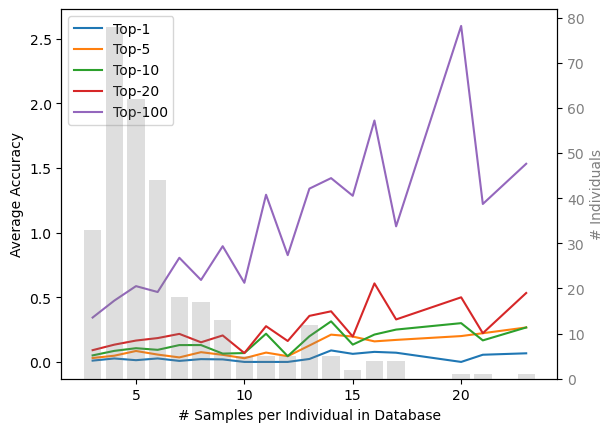

In [9]:
ch1.test(test_loader, backbone= MD)

r31.evaluate_model(ch1, train_loader, test_loader, ba = MD, show_matches=False, show_tsne=False)

# Do Retrieval on Elephant-level SEEK codes
- Technically this should be better 

# Baseline 3.2 

In [5]:
code = 'baseline-3-miew'
r32 = Retrieval(experiment_code=code)

miew = Backbone(with_ears = True, lr = 1e-4, model_name = "MiewID-msv3", experiment_code=code)
ch2 = ConceptHead(experiment_code=code)
#ch2.train(ch_train_loader, val_loader=ch_val_loader, backbone= miew, num_epochs=200)
#ch2.test(ch_test_loader, backbone= miew)

Building Model Backbone for efficientnetv2_rw_m model
config.model_name efficientnetv2_rw_m
model_name efficientnetv2_rw_m
final_in_features 2152


## Implementing CHAIR

In [3]:
def no_intervention(predicted_concepts, true_concepts, correction_probability = 0.0):
    return predicted_concepts

def intervene(predicted_concepts, true_concepts, correction_probability = 0.5):
    for i in range(predicted_concepts.shape[0]):
        if torch.rand(1).item() < correction_probability:
            predicted_concepts[i] = true_concepts[i]
    # To-do correction
    return predicted_concepts

def perfect_correction(predicted_concepts, true_concepts, correction_probability = 1.0):
    return true_concepts

In [5]:
code = 'chair'
ba = Backbone(pretraining='savannah_elephants', experiment_code=code)
ba.freeze()

ch = ConceptHead(experiment_code=code)
ch.test(train_loader,ba)
ch.freeze()

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

ConceptHead - Test Loss: 0.0607, Test Accuracy: 86.37%
sex Accuracy: 96.47%
age Accuracy: 97.83%
right_tusk Accuracy: 87.48%
left_tusk Accuracy: 88.34%
R_tear_1 Accuracy: 73.90%
R_hole_1 Accuracy: 82.18%
R_tear_2 Accuracy: 78.34%
R_hole_2 Accuracy: 87.73%
L_tear_1 Accuracy: 72.08%
L_hole_1 Accuracy: 83.24%
L_tear_2 Accuracy: 77.64%
L_hole_2 Accuracy: 87.38%
right_extreme Accuracy: 91.82%
left_extreme Accuracy: 89.45%
ear_special Accuracy: 93.19%
body_special Accuracy: 94.85%
average Accuracy: 86.37%
whole_code Accuracy: 37.25%


wandb: Currently logged in as: antoinesalaun (antoinesalaun-massachusetts-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Concept head parameters require gradients: False 
Backbone parameters require gradients: True 
Projector parameters require gradients: True
Epoch 1/10 - Train Loss: 7.1553, BATCH-Recall@1: 0.76%, --- EPOCH - Recall@1: 2.22%, Recall@5: 5.05%, Recall@20: 15.30%, Recall@100: 40.18%
Epoch 2/10 - Train Loss: 7.0532, BATCH-Recall@1: 0.51%, --- EPOCH - Recall@1: 2.73%, Recall@5: 5.65%, Recall@20: 14.24%, Recall@100: 40.74%
Epoch 3/10 - Train Loss: 6.9779, BATCH-Recall@1: 0.81%, --- EPOCH - Recall@1: 1.97%, Recall@5: 5.40%, Recall@20: 13.63%, Recall@100: 38.77%
Epoch 4/10 - Train Loss: 6.9125, BATCH-Recall@1: 0.35%, --- EPOCH - Recall@1: 2.68%, Recall@5: 6.31%, Recall@20: 14.49%, Recall@100: 38.87%
Epoch 5/10 - Train Loss: 6.8601, BATCH-Recall@1: 0.76%, --- EPOCH - Recall@1: 2.68%, Recall@5: 6.16%, Recall@20: 14.79%, Recall@100: 39.98%
Epoch 6/10 - Train Loss: 6.8013, BATCH-Recall@1: 0.81%, --- EPOCH - Recall@1: 2.57%, Recall@5: 5.96%, Recall@20: 15.04%, Recall@100: 40.28%
Epoch 7/10 - Train L

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


Epoch 10/10 - Train Loss: 6.6629, BATCH-Recall@1: 0.66%, --- EPOCH - Recall@1: 1.87%, Recall@5: 4.85%, Recall@20: 12.12%, Recall@100: 37.96%


batch_recall@1,▇▃█▁▇█▃▃▃▆
epoch,▁▂▃▃▄▅▆▆▇█
epoch_recall@1,▄█▂██▇▆▁▃▁
epoch_recall@100,▆▇▃▃▆▆▆█▄▁
epoch_recall@20,█▆▄▆▇▇▄▄▄▁
epoch_recall@5,▂▅▄█▇▆▅▄▄▁
train_loss,█▇▅▅▄▃▂▂▁▁
batch_recall@1,0.65524
epoch,10
epoch_recall@1,1.86774
epoch_recall@100,37.96063


evaluating projector
Train Recalls:
Recall@1: 1.82%
Recall@5: 4.85%
Recall@10: 8.08%
Recall@20: 13.28%
Recall@100: 37.96%
Test Recalls:
Recall@1: 5.64%
Recall@5: 10.81%
Recall@10: 14.62%
Recall@20: 21.10%
Recall@100: 50.34%


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:364: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


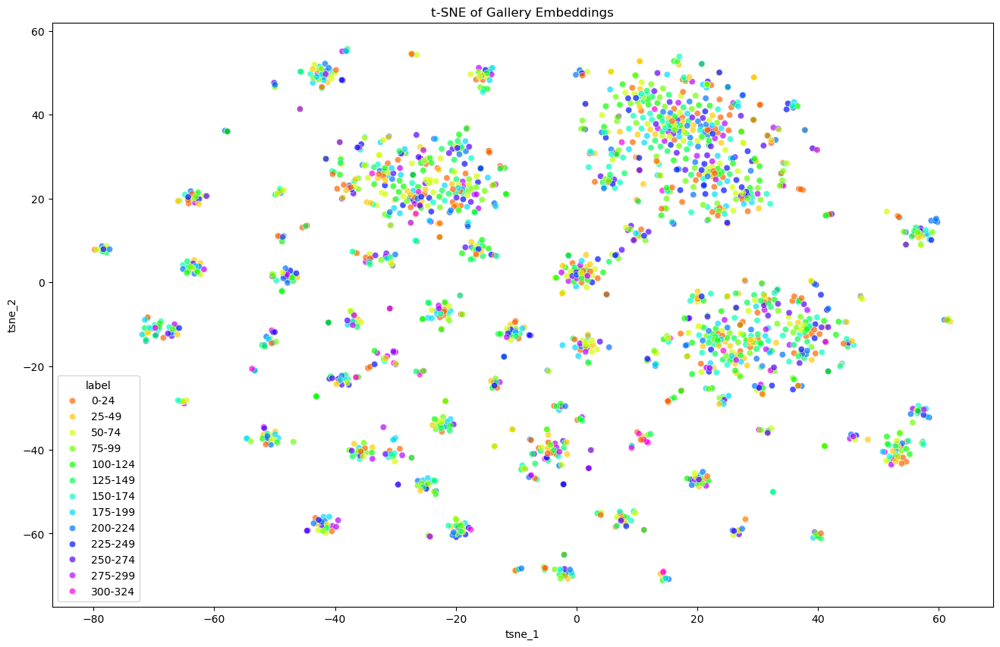

<Figure size 640x480 with 0 Axes>

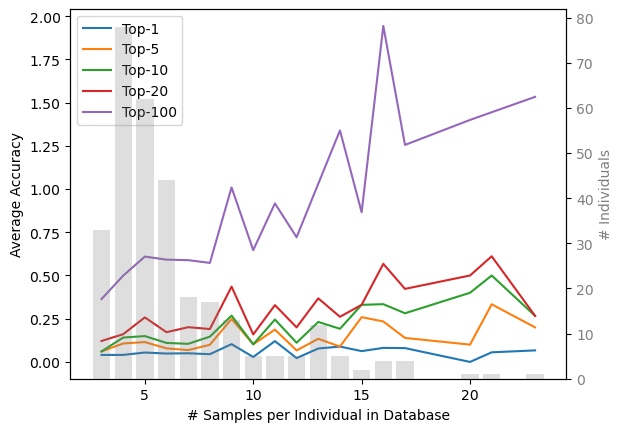

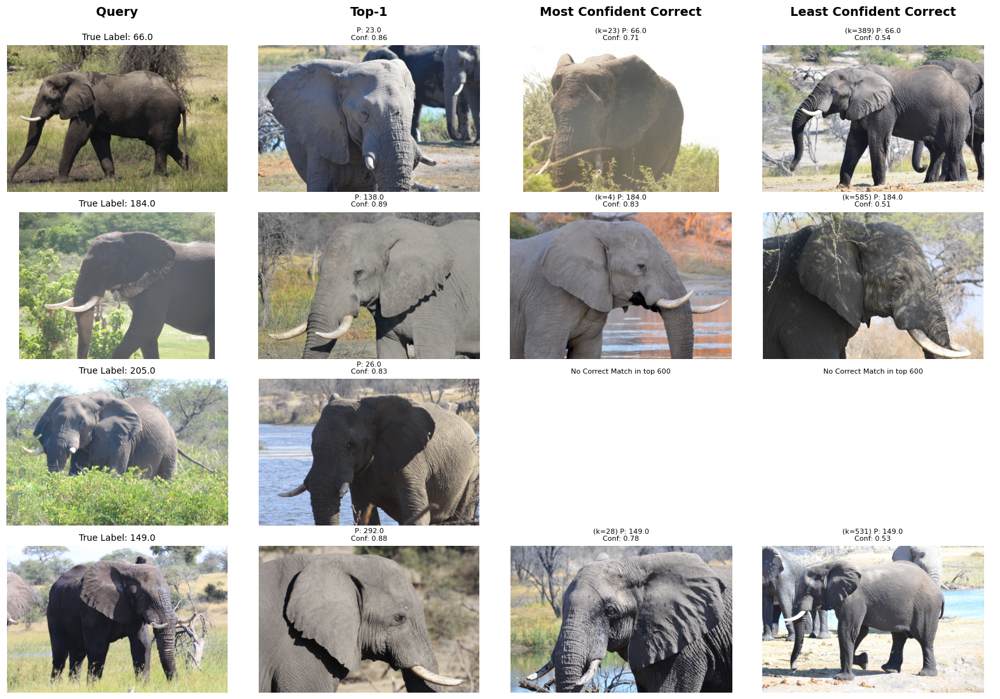

<Figure size 640x480 with 0 Axes>

In [10]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

r = Retrieval(experiment_code=code)

ba.unfreeze()

pr = Projector(criterion = 'ArcFace', lr = 0.0001, scale = 64, margin = 0.5, experiment_code=code)
pr.train(train_loader, train_loader, ba, ch, num_epochs=10)

r.evaluate_model(pr, train_loader, test_loader, ba, ch)

Concept head parameters require gradients: False 
Backbone parameters require gradients: False 
Projector parameters require gradients: True
Epoch 1/20 - Train Loss: 7.0666, BATCH-Recall@1: 3.49%, --- EPOCH - Recall@1: 6.71%, Recall@5: 12.92%, Recall@20: 21.96%, Recall@100: 46.95%
Epoch 2/20 - Train Loss: 7.0056, BATCH-Recall@1: 3.24%, --- EPOCH - Recall@1: 6.66%, Recall@5: 12.87%, Recall@20: 21.96%, Recall@100: 46.85%
Epoch 3/20 - Train Loss: 6.9559, BATCH-Recall@1: 3.33%, --- EPOCH - Recall@1: 6.66%, Recall@5: 12.82%, Recall@20: 22.01%, Recall@100: 46.69%
Epoch 4/20 - Train Loss: 6.9096, BATCH-Recall@1: 3.99%, --- EPOCH - Recall@1: 6.66%, Recall@5: 12.82%, Recall@20: 21.96%, Recall@100: 46.74%
Epoch 5/20 - Train Loss: 6.8634, BATCH-Recall@1: 3.02%, --- EPOCH - Recall@1: 6.66%, Recall@5: 12.87%, Recall@20: 21.86%, Recall@100: 46.79%
Epoch 6/20 - Train Loss: 6.8261, BATCH-Recall@1: 3.73%, --- EPOCH - Recall@1: 6.71%, Recall@5: 12.82%, Recall@20: 21.86%, Recall@100: 46.74%
Epoch 7/20 - 

/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:364: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


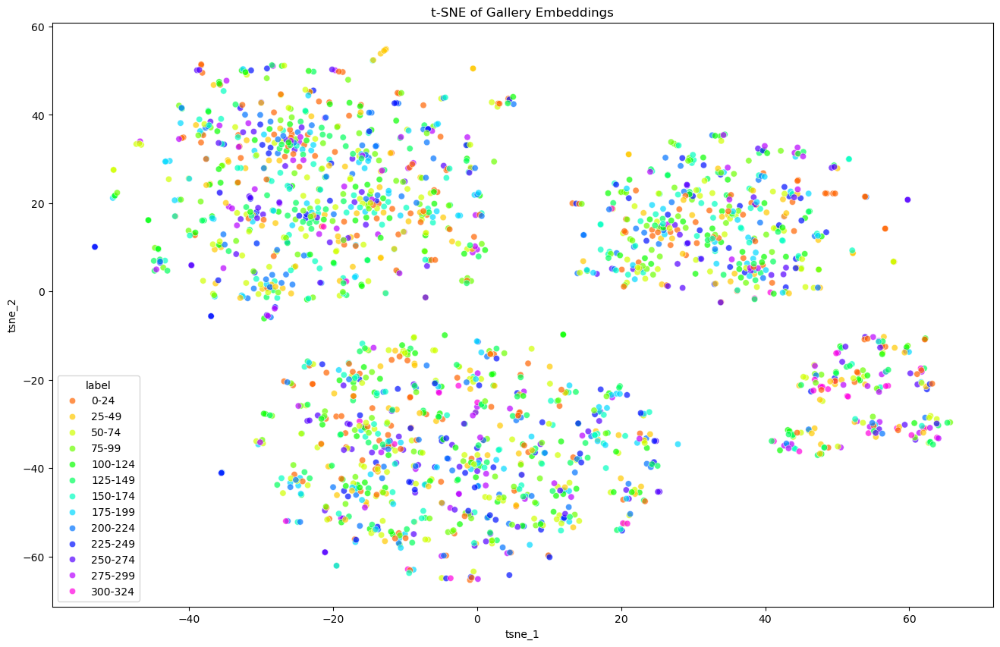

<Figure size 640x480 with 0 Axes>

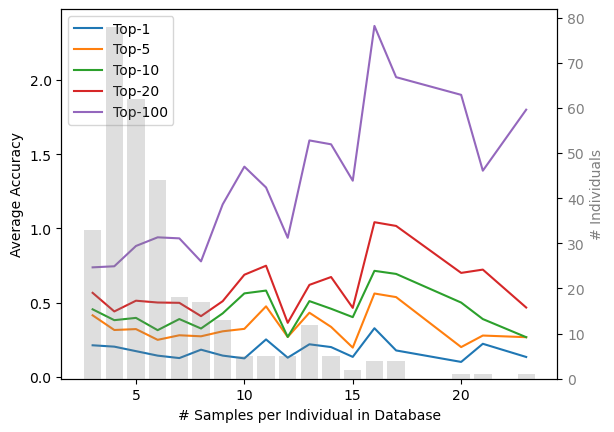

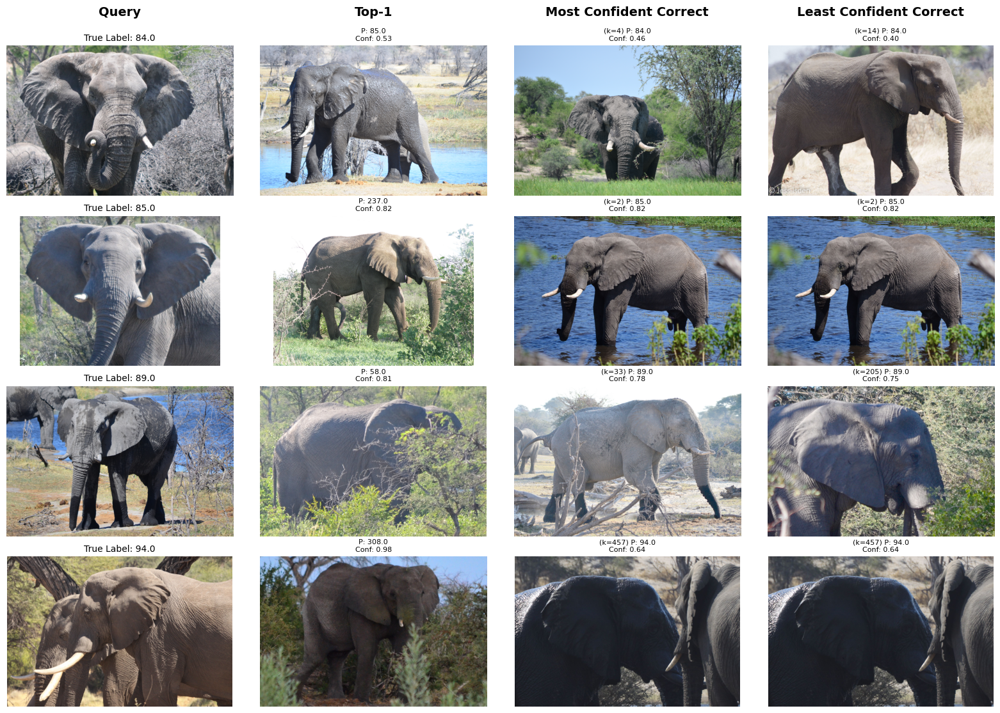

<Figure size 640x480 with 0 Axes>

In [17]:
train_loader = DataLoader(train_subset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=512, shuffle=True)

r = Retrieval(experiment_code=code)

# Training with 1 lazer and batch norm
pr = Projector(criterion = 'ArcFace', lr = 5e-4, scale = 64, margin = 0.5, experiment_code=code)
pr.train(train_loader, train_loader, ba, ch, num_epochs=20)

r.evaluate_model(pr, train_loader, test_loader, ba, ch)

In [21]:
r_test = Retrieval(experiment_code='trash')
ks = [1, 5, 20, 100]


gallery_embeddings, gallery_labels = pr.collect_embeddings(train_loader, ba, ch, intervention_fn = perfect_correction)
query_embeddings, query_labels = pr.collect_embeddings(test_loader, ba, ch)

gallery_sim_matrix = r_test.cosine_similarity_matrix(gallery_embeddings)
train_recalls = {k: r_test.compute_recall_at_k(gallery_sim_matrix, gallery_labels, gallery_labels, k=k) for k in ks}

# Test with new queries

test_similarity_matrix = r_test.cosine_similarity_matrix(query_embeddings, gallery_embeddings)

# Compute Recall@k
test_recalls = {k: r_test.compute_recall_at_k(test_similarity_matrix, query_labels, gallery_labels, k=k) for k in ks}

print("Train Recalls:")
for k in ks:
    print(f"Recall@{k}: {train_recalls[k]*100:.2f}%")

print("Test Recalls:")
for k in ks:
    print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")


Train Recalls:
Recall@1: 6.31%
Recall@5: 12.72%
Recall@20: 22.51%
Recall@100: 47.65%
Test Recalls:
Recall@1: 18.51%
Recall@5: 29.32%
Recall@20: 42.57%
Recall@100: 65.96%


**Hypothesis** : Projector is helpful because it's light. Thus we can train with larger batches. As we work with rare positive pairs, this allows to put more positive matches in the same batch, allowing ArcFace to perform better.   

# Hyperparameter search

In [7]:
lrs = [1e-4, 5e-4, 1e-3]
scales = [1, 8, 64]
margins = [0.1, 0.5, 2]


for lr in lrs:
    for scale in scales:
        for margin in margins:
            code = 'chair_hyperparam_lr=' + str(lr) + '_sc=' + str(scale) + '_marg=' + str(margin)
            print('=======================', code, '=======================')
            r = Retrieval(experiment_code=code)

            pr = Projector(criterion = 'ArcFace', lr =lr, scale = scale, margin = margin, experiment_code=code)
            pr.train(train_loader, train_loader, ba, ch, num_epochs=50)

            r.evaluate_model(pr, train_loader, test_loader, ba, ch)

Concept head parameters require gradients: False 
Backbone parameters require gradients: False 
Projector parameters require gradients: True
Epoch 1/20 - Train Loss: 5.7391, BATCH-Recall@1: 6.66%, --- EPOCH - Recall@1: 6.66%, Recall@5: 12.27%, Recall@20: 21.45%, Recall@100: 46.69%
Epoch 2/20 - Train Loss: 5.7390, BATCH-Recall@1: 6.66%, --- EPOCH - Recall@1: 6.66%, Recall@5: 12.27%, Recall@20: 21.45%, Recall@100: 46.64%


KeyboardInterrupt: 